# Motion Features and Analysis

Raw BVH data gives you joint angles and root positions, but many applications need richer features derived from the motion. How fast is each joint moving? Which foot is on the ground? What direction is the character facing?

The `pybvh.features` module computes these properties directly from the `Bvh` object. All functions return NumPy arrays, ready to use as model inputs or for analysis. This tutorial covers:

- Joint velocities and accelerations (linear)
- Angular velocities (rotational)
- Root trajectory on the ground plane
- Foot contact detection
- The combined feature array (`to_feature_array()`) and its column layout

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

import pybvh
from pybvh import features
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
bvh_folder = REPO_ROOT / "bvh_data"
bvh = pybvh.read_bvh_file(bvh_folder / 'bvh_test1.bvh')
print(bvh)

24 elements in the Hierarchy, 75 frames at 30.0 fps (frame_time=0.033333s)


# Joint velocities

**Joint velocity** measures how fast each joint's 3D position changes over time. It's a finite-difference time derivative of the forward kinematics positions.

Two parameters control the computation:

- **`stencil`** — `"central"` (default, second-order accurate) or `"forward"` (first-order).
- **`pad`** — `"edge"` (default, output has same shape as input; boundaries filled with one-sided differences) or `"none"` (drop boundary frames).

Defaults give `np.gradient` semantics with shape `(F, J, 3)` — row `i` aligns with source frame `i`, so velocities stack cleanly with other per-frame features. `J` is the number of non-end-site joints (matches `joint_angles` axis 1). The full shape matrix:

| `stencil` × `pad` | Shape |
|---|---|
| central, edge (default) | `(F, J, 3)` |
| central, none | `(F-2, J, 3)` |
| forward, edge | `(F, J, 3)` |
| forward, none | `(F-1, J, 3)` |

Need end-site rows too? Use `bvh.node_velocities()` — same math, shape `(F, N, 3)` where `N` is all nodes including end sites. Useful when you care about extremity (toe tip / fingertip / head) trajectories.

In [2]:
velocities = bvh.joint_velocities()

print(f'Input frames:    {bvh.frame_count}')
print(f'Velocity shape:  {velocities.shape}  (F, joint_count, 3)')

Input frames:    75
Velocity shape:  (75, 29, 3)  (F, num_nodes, 3)


By default, velocities are in **units per second**. Set `in_frames=True` to get units per frame instead — useful when you want representations that don't depend on the clip's frame rate.

In [3]:
vel_per_sec = bvh.joint_velocities()                  # default: units/second
vel_per_frame = bvh.joint_velocities(in_frames=True)  # units/frame

print(f'Velocity per second (frame 10, joint 0): {vel_per_sec[10, 0]}')
print(f'Velocity per frame  (frame 10, joint 0): {vel_per_frame[10, 0]}')
print(f'Ratio (should be 1/frame_time = {1/bvh.frame_time:.1f}): '
      f'{vel_per_sec[10, 0, 0] / vel_per_frame[10, 0, 0]:.1f}')

Velocity per second (frame 10, joint 0): [ 3.7935 -0.702   1.671 ]
Velocity per frame  (frame 10, joint 0): [ 0.1265 -0.0234  0.0557]
Ratio (should be 1/frame_time = 30.0): 30.0


Let's plot the speed (magnitude of velocity) of a specific joint over time to see the motion dynamics — peaks correspond to fast movements, valleys to rest.

In [ ]:
bvh.play()

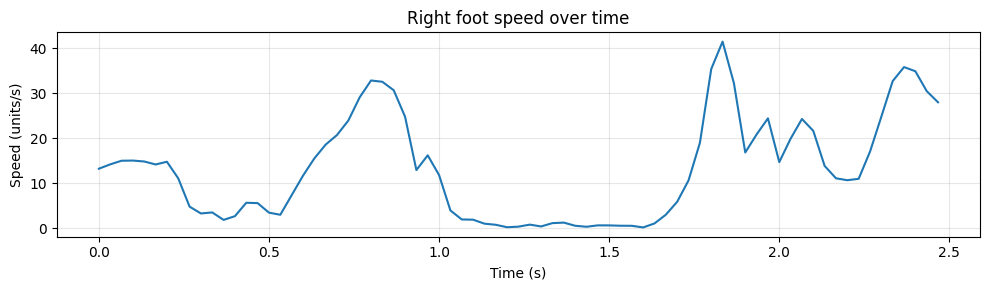

In [4]:
right_foot_idx = bvh.joint_index['RightFoot']
speed = np.linalg.norm(vel_per_sec[:, right_foot_idx], axis=-1)

t = np.arange(bvh.frame_count) * bvh.frame_time
plt.figure(figsize=(10, 3))
plt.plot(t, speed)
plt.xlabel('Time (s)')
plt.ylabel('Speed (units/s)')
plt.title('Right foot speed over time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Joint accelerations

**Acceleration** applies the chosen `stencil` twice to the positions. Same parameters as `joint_velocities`; the only difference is that `pad="none"` drops twice as many frames (`(F-4, J, 3)` for central, `(F-2, J, 3)` for forward).

Under the defaults the composition identity holds exactly: `np.gradient(joint_velocities(), dt, axis=0)` equals `joint_accelerations()`.

In [5]:
accelerations = bvh.joint_accelerations()

print(f'Acceleration shape: {accelerations.shape}  (F, joint_count, 3)')

Acceleration shape: (75, 29, 3)  (F, num_nodes, 3)


# Angular velocities

**Angular velocity** measures how fast rotations change. Output is an axis-angle vector per joint per frame: the direction is the rotation axis, the magnitude is the rotation angle (radians/second by default; pass `degrees=True` to get degrees/second).

Same `stencil`/`pad` matrix as `joint_velocities`, applied to rotation matrices rather than positions:

- `stencil="central"` — two-step relative rotation $R_{\text{rel}} = R_{i-1}^\top R_{i+1}$, axis-angle halved.
- `stencil="forward"` — one-step $\omega_i = \log(R_i^\top R_{i+1})$, the canonical motion-capture formula.

Defaults (central, edge) time-align with linear velocities so `ω[i]` and `vel[i]` both mean "rate of change at frame `i`".

In [6]:
ang_vel = bvh.angular_velocities()

print(f'Angular velocity shape: {ang_vel.shape}  (F, num_joints, 3)')
print(f'\nAngular velocity of Hips (frame 10): {ang_vel[10, 0]} rad/s')

Angular velocity shape: (75, 24, 3)  (F, num_joints, 3)

Angular velocity of Hips (frame 10): [ 0.0037 -0.2963 -0.8882] rad/s


Angular velocities operate on **joints only** (shape axis J) — end sites have no rotation channels. Joint indexing is consistent across `joint_angles`, `joint_velocities`, `joint_accelerations`, and `angular_velocities`: `bvh.joint_index['name']` indexes the same row in all four. To get linear velocities including end sites, use `bvh.node_velocities()` and index with `bvh.node_index`.

Plotting angular-velocity magnitude over time for a single joint shows when that joint is rotating fastest — analogous to the speed plot above, but in rotational units.

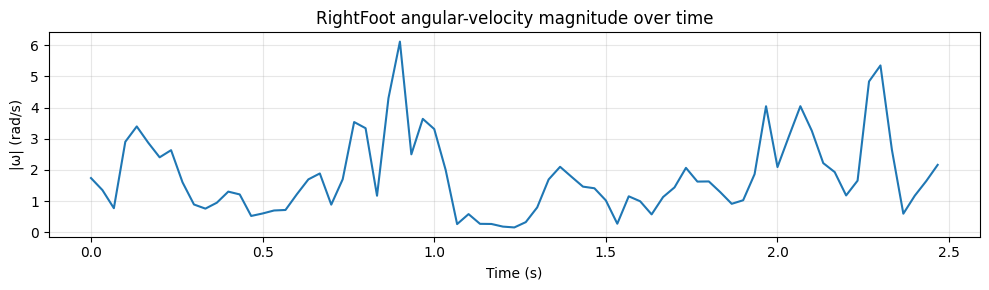

In [7]:
right_foot_idx = bvh.joint_index['RightFoot']
ang_speed = np.linalg.norm(ang_vel[:, right_foot_idx], axis=-1)

plt.figure(figsize=(10, 3))
plt.plot(t, ang_speed)
plt.xlabel('Time (s)')
plt.ylabel('|ω| (rad/s)')
plt.title(f'RightFoot angular-velocity magnitude over time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Root trajectory

The **root trajectory** summarizes the character's global movement on the ground plane as a compact `(F, 4)` array per frame:

| Column | Description |
|---|---|
| `ground_pos_a` | Position on the first ground-plane axis |
| `ground_pos_b` | Position on the second ground-plane axis |
| `heading_sin` | Sine of the heading angle (facing direction) |
| `heading_cos` | Cosine of the heading angle (facing direction) |

The heading is measured as the angle between the character's current forward direction and the rest-pose forward direction, projected onto the ground plane. Storing it as a `(sin, cos)` pair instead of a raw angle avoids the $\pm\pi$ discontinuity when the character turns through straight-back.

This representation is standard in motion generation pipelines (HumanML3D, MDM, etc.).

In [8]:
trajectory = bvh.root_trajectory()

print(f'Root trajectory shape: {trajectory.shape}  (F, 4)')
print(f'\nFirst 5 frames:')
print(trajectory[:5])

Root trajectory shape: (75, 4)  (F, 4)

First 5 frames:
[[ -0.8231 -10.8992   0.999    0.0457]
 [ -0.9068 -10.9822   0.9992   0.0395]
 [ -0.9787 -11.047    0.9996   0.0267]
 [ -1.0304 -11.1019   1.       0.0063]
 [ -1.0641 -11.1313   0.9997  -0.024 ]]


The ground-plane position is easy to visualize as a top-down 2D path — `bvhplot.trajectory()` does this (covered in Tutorial 4). Passing `facing_arrows=True` overlays arrowheads at ~10 evenly-spaced frames showing the character's facing direction at those frames, using the heading sin/cos columns directly:

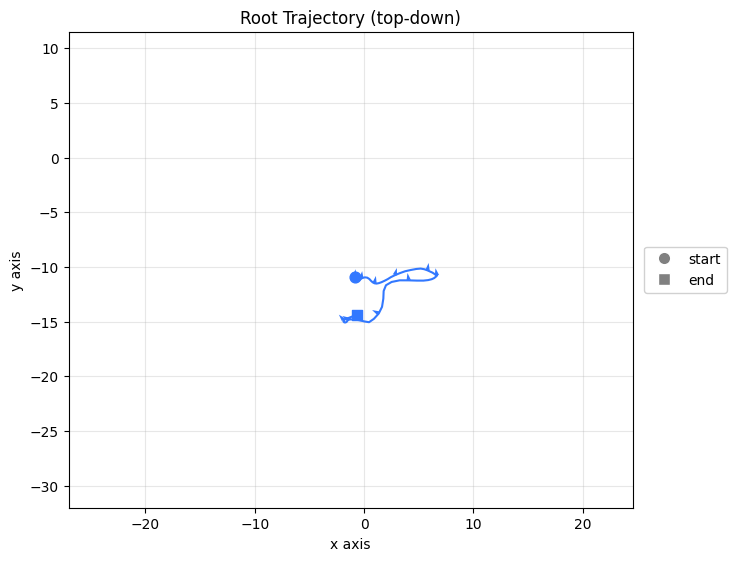

In [9]:
fig, ax = pybvh.bvhplot.trajectory(bvh, facing_arrows=True)
plt.show()

# Foot contact detection

**Foot contacts** are binary labels per frame per foot joint, indicating whether that foot is on the ground. They matter in many pipelines — preventing foot sliding in generated motions, detecting gait phases, auxiliary labels for ML models.

Note: "on the ground" definition here excludes sliding on purpose.

Three detection methods, each looking at one signal:

- **`"velocity"`**: foot is in contact when its speed is below a threshold. False positive when a foot is paused mid-air (low speed but lifted).
- **`"height"`**: foot is in contact when it's close to the estimated floor. False positive when a foot is sliding along the floor (low height but moving — not "planted" in the usual ML sense).
- **`"combined"`** (default): both signals must agree (logical AND). Follows the HuMoR / Kovar 2002 heuristic; catches the failure modes of each signal on its own.

In [10]:
# Default: method='combined'
contacts = bvh.foot_contacts()
print(f'Foot contacts shape: {contacts.shape}  (F, num_feet)')

Foot contacts shape: (75, 2)  (F, num_feet)


Visualizing the three methods side by side on the same clip shows where they disagree — **black pixels** are contact frames:

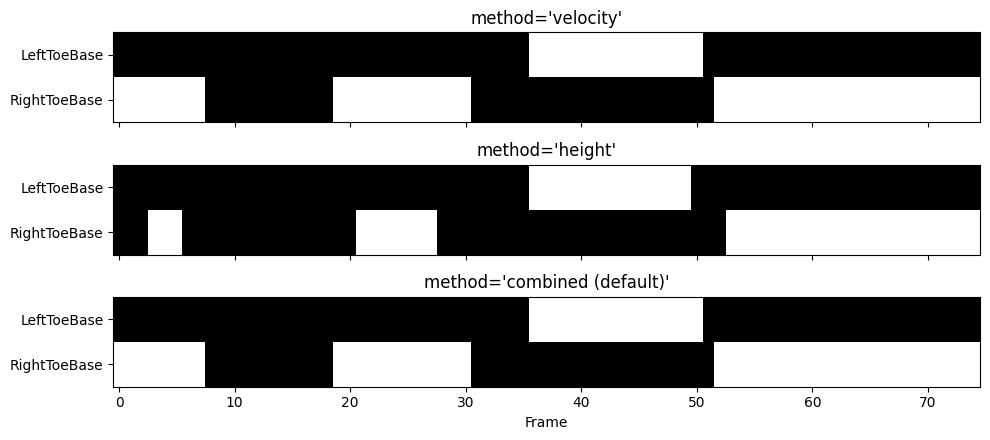

In [11]:
foot_names = bvh.auto_detect_foot_joints()

contacts_vel = bvh.foot_contacts(method='velocity')
contacts_ht  = bvh.foot_contacts(method='height')
contacts_comb = bvh.foot_contacts(method='combined')

fig, axes = plt.subplots(3, 1, figsize=(10, 4.5), sharex=True)
for ax, contacts, title in zip(
    axes,
    [contacts_vel, contacts_ht, contacts_comb],
    ['velocity', 'height', 'combined (default)'],
):
    ax.imshow(contacts.T, aspect='auto', cmap='Greys', interpolation='nearest')
    ax.set_yticks(range(len(foot_names)))
    ax.set_yticklabels(foot_names)
    ax.set_title(f"method='{title}'")
axes[-1].set_xlabel('Frame')
plt.tight_layout()
plt.show()

The defaults auto-scale thresholds with skeleton size (no tuning needed across cm- vs m-scale rigs) and apply 100 ms temporal smoothing to remove flickers. Pass `min_contact_duration=0, min_gap_duration=0` for raw per-frame output.

# The feature array — combining everything

`to_feature_array()` composes root position, joint rotations (in any representation), velocities, and foot contacts into a single flat array. This is the function you typically call when preparing data for training.

Under the defaults (`stencil="central", pad="edge"`), all blocks align at shape `(F, ...)` so row `i` corresponds to frame `i` across every block. Other `stencil`/`pad` combinations propagate the same way they do for `joint_velocities` (see that section for the full matrix).

In [12]:
# Full feature array: root_pos + 6D rotations + velocities + foot contacts
feat_full = bvh.to_feature_array(
    representation='6d',
    include_velocities=True,
    include_foot_contacts=True,
)
print(f'Full feature array: shape = {feat_full.shape}  '
      f'({bvh.frame_count} frames, D={feat_full.shape[1]})')

Full feature array: shape = (75, 236)  (75 frames, D=236)


## Unpacking the feature array

Once the array is packed, downstream code typically needs to slice specific blocks back out. `feature_array_layout(...)` returns a `{block_name: slice}` dict that maps each block to its column range — no need to count columns by hand. It's a pure function (it doesn't need a `Bvh` at all, and is also exposed at module level as `features.feature_array_layout(...)`), so you can call it for model-shape setup before any data is loaded.

In [13]:
layout = bvh.feature_array_layout(
    num_feet=len(foot_names),
    representation='6d',
    include_velocities=True,
    include_foot_contacts=True,
)
for name, sl in layout.items():
    print(f'  {name:14s}  columns {sl.start:3d}:{sl.stop:3d}  '
          f'(width {sl.stop - sl.start})')

  root_pos        columns   0:  3  (width 3)
  rotations       columns   3:147  (width 144)
  velocities      columns 147:234  (width 87)
  foot_contacts   columns 234:236  (width 2)


In [14]:
rotations_block = feat_full[:, layout['rotations']]
velocities_block = feat_full[:, layout['velocities']]
contacts_block   = feat_full[:, layout['foot_contacts']]

print(f'Rotations block: {rotations_block.shape}')
print(f'Velocities block: {velocities_block.shape}')
print(f'Foot contacts block: {contacts_block.shape}')

Rotations block: (75, 144)
Velocities block: (75, 87)
Foot contacts block: (75, 2)


# Summary

| Function | Returns | Shape (defaults) |
|---|---|---|
| `bvh.joint_velocities()` | Linear velocity of joint positions (non-end-site) | `(F, J, 3)` |
| `bvh.joint_accelerations()` | Linear acceleration (non-end-site) | `(F, J, 3)` |
| `bvh.node_velocities()` | Same, including end sites | `(F, N, 3)` |
| `bvh.node_accelerations()` | Same, including end sites | `(F, N, 3)` |
| `bvh.angular_velocities()` | Rotation rate (axis-angle) | `(F, J, 3)` |
| `bvh.root_trajectory()` | Ground-plane pos + heading sin/cos | `(F, 4)` |
| `bvh.root_trajectory(include_velocities=True)` | + ground vel + heading vel | `(F, 7)` |
| `bvh.foot_contacts()` | Binary contact labels (method='combined') | `(F, num_feet)` |
| `bvh.auto_detect_foot_joints()` | Detected foot joint names | `list[str]` |
| `bvh.to_feature_array()` | Combined flat array | `(F, D)` |
| `bvh.feature_array_layout(...)` | Column slice map | `dict[str, slice]` |

`J` = non-end-site joints (matches `joint_angles` axis 1), `N` = all nodes including end sites (matches `node_positions` axis 1). The `joint_*` versions are what most ML pipelines want — they index-align with `joint_angles`, `angular_velocities`, and the rotation block of `to_feature_array`. The `node_*` versions are for extremity tracking when end-site positions matter. Defaults are `stencil="central", pad="edge"` on every velocity-like function — central interior + one-sided boundaries, output shape matches input. Pass `stencil="forward", pad="none"` for strict forward differences matching pre-v3 pybvh (`(F-1, ...)` / `(F-2, ...)`); `stencil="central", pad="none"` drops both boundaries symmetrically. `bvh.node_positions(centered='skeleton')` gives skeleton-centered positions (equivalent to root-relative positions in an old v0.5 API).

# What's next

- **Tutorial 7 — Batch Processing**: loading directories of BVH files, normalization statistics, and dataset preparation at scale.